## IMPORT LIBRARIES

In [84]:
import numpy as np
import torch
from torch import nn
import tqdm

import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torch.nn.init as init

from sklearn.metrics import accuracy_score


In [85]:
torch.cuda.is_available()

False

### Load data

In [86]:
# Use the following code to load and normalize the dataset for training and testing
# It will downlad the dataset into data subfolder (change to your data folder name)
train_dataset = torchvision.datasets.FashionMNIST('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/data/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))

test_dataset = torchvision.datasets.FashionMNIST('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/data/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))

### Create validation set and split data

In [87]:
# Use the following code to create a validation set of 10%
train_indices, val_indices, _, _ = train_test_split(
    range(len(train_dataset)),
    train_dataset.targets,
    stratify=train_dataset.targets,
    test_size=0.1,
)

# Generate training and validation subsets based on indices
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)

### Set batch size and iterate over batches and samples for training, validation, and testing

In [88]:

# set batches sizes
train_batch_size = 128 #Define train batch size
test_batch_size  = 64 #Define test batch size (can be larger than train batch size)

# Define dataloader objects that help to iterate over batches and samples for
# training, validation and testing
train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
val_batches = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)
                                           
num_train_batches=len(train_batches)
num_val_batches=len(val_batches)
num_test_batches=len(test_batches)

print(num_train_batches)
print(num_val_batches)
print(num_test_batches)

422
47
157


### visualize

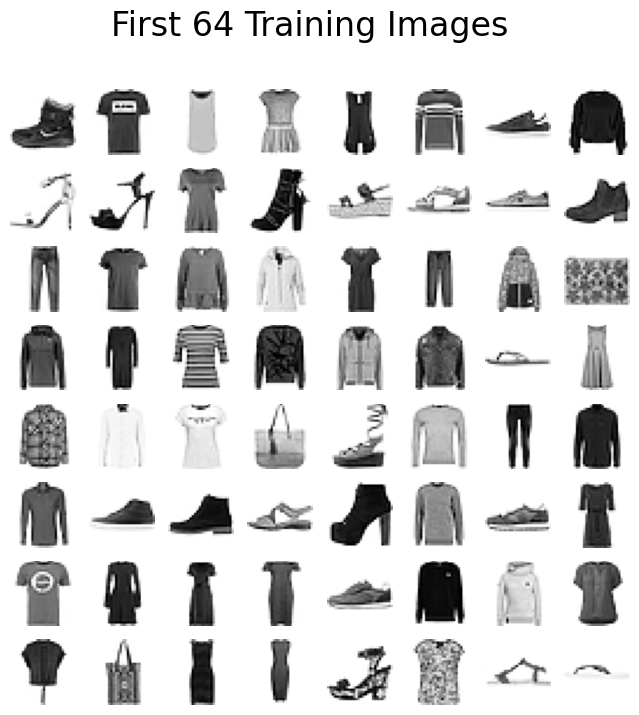

In [89]:
#Sample code to visulaize the first sample in first 16 batches 

batch_num = 0
for train_features, train_labels in train_batches:

    if batch_num == 16:
        break    # break here

    batch_num = batch_num +1
    '''print(f"Feature batch shape: {train_features.size()}")
    print(f"Labels batch shape: {train_labels.size()}")'''

    img = train_features[0].squeeze()
    label = train_labels[0]
    '''plt.imshow(img, cmap="gray")
    plt.show()
    print(f"Label: {label}")'''



# Sample code to plot N^2 images from the dataset
def plot_images(XX, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))

    for i in range(N):
        for j in range(N):
            ax[i,j].imshow(XX[(N)*i+j], cmap="Greys")
            ax[i,j].axis("off")
        fig.suptitle(title, fontsize=24)

plot_images(train_dataset.data[:64], 8, "First 64 Training Images" )

## Define FCN

In [90]:
#Define your (As Cool As It Gets) Fully Connected Neural Network 
class ACAIGFCN(nn.Module):
    #Initialize model layers, add additional arguments to adjust
    def __init__(self, input_dim, hidden_lays, output_dim, dropout_prob, init, batchnorm): 
        super(ACAIGFCN, self).__init__()
        #Define the network layer(s) and activation function(s)
        # create empty layers list to add layers to
        lays = []
        # set initial prev_dim as the input_dim
        prev_dim = input_dim

        # parse through each individual hidden layer, y=xAT+b
        for hidden_dim in hidden_lays:
            # apply linear transformation of input, append to layers
            lays.append(nn.Linear(prev_dim, hidden_dim))
            # apply batch norm
            if batchnorm=='yes':
                lays.append(nn.BatchNorm1d(hidden_dim))  
            # Applies theo rectified linear unit function element-wise, append to layers (introduces nonlinearlity)
            lays.append(nn.ReLU())
            # apply dropout
            lays.append(nn.Dropout(p=dropout_prob))
            # reset prev_dim as the current, hidden_dim
            prev_dim = hidden_dim
        
        # do one more linear transformation, getting to output_dim
        # no need for relu activation b/c cross entropy loss expects raw class scores
        lays.append(nn.Linear(prev_dim, output_dim))

        # sequential container - models are added to it as they are passed in constructor
        self.model = nn.Sequential(*lays) # hid,  hid2 ..

        if init=='RN' or init=='XN' or init=='KU':
            # apply initiation
            self.init_weights()
 
    def forward(self, input):
        #Define how your model propagates the input through the network
        return self.model(input)
    
    def init_weights(self):
        for layer in self.model:
            # Only initialize Linear layers
            if isinstance(layer, nn.Linear):
                if init=='RN':  
                    # Normal distribution
                    init.normal_(layer.weight, mean=0.0, std=0.01)
                elif init=='XN':
                    # Normal distribution
                    init.xavier_normal_(layer.weight) 
                elif init=='KU':
                    # Normal distribution
                    init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                # Initialize bias to zero
                init.zeros_(layer.bias)  
 
    

## Run Model
### Set different hyperparameters

In [91]:
layers1 = [128, 256, 512]
layers2 = [128,128,128]
layers3 = [64,64]
layers4= [128]
layers5 = [128,65]
layers_base = [512,256]

#epochs = 30
epochs = 50

'''train_batch_size = 512
test_batch_size = 256'''
train_batch_size = 128
test_batch_size = 64


### Train and evaluate model

In [92]:
# create a fxn to easily adjust parameters
def train_and_eval(hidden_lays, learning_rate, epochs, train_batch_size, opt, dropout_prob, init, batchnorm):
    # Initialize neural network model with input, output and hidden layer dimensions
    model = ACAIGFCN(input_dim = 784, hidden_lays= hidden_lays, output_dim = 10, dropout_prob=dropout_prob, init=init, batchnorm=batchnorm) 

    # Define dataloader objects that help to iterate over batches and samples for
    # training, validation and testing
    train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
    val_batches = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)

    num_train_batches=len(train_batches)
    num_val_batches=len(val_batches)

    train_loss_list = np.zeros((epochs,))
    validation_accuracy_list = np.zeros((epochs,))

    # Define loss function  and optimizer
    # Use Cross Entropy loss from torch.nn to define loss function
    loss_func = nn.CrossEntropyLoss()

    # Use optimizers from torch.optim to define optimizer
    if opt=='SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    elif opt=='Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    elif opt=='RMS':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate)

    # Iterate over epochs, batches with progress bar and train+ validate the ACAIGFCN
    # Track the loss and validation accuracy
    for epoch in tqdm.trange(epochs):
        # initialize running loss as 0
        running_loss = 0.0

        # ACAIGFCN Training 
        for train_features, train_labels in train_batches:
            # Set model into training mode
            model.train()
            
            # Reshape images into a vector
            train_features = train_features.reshape(-1, 28*28)

            # Reset gradients, 
            optimizer.zero_grad() 
            #Calculate training loss on model
            outputs = model(train_features)
            loss = loss_func(outputs, train_labels)
            # Perform optimization, back propagation
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
    
        # Record loss for the epoch by dividing sum of running loss for the epoch, dividing by length of train batches
        train_loss_list[epoch] = running_loss / num_train_batches
        
        

        val_acc_sum = 0
        # ACAIGFCN Validation
        for val_features, val_labels in val_batches:
            
            # Telling PyTorch we aren't passing inputs to network for training purpose
            with torch.no_grad(): 
                model.eval()
                
                # Reshape validation images into a vector
                val_features = val_features.reshape(-1, 28*28)
            
                # Compute validation outputs (targets) 
                outputs = model(val_features)  # Forward pass
                _, predicted = torch.max(outputs, 1)  # Get predicted class labels

                # add to lists
                val_acc = accuracy_score(val_labels, predicted)
                val_acc_sum += val_acc
                
                
        # Record accuracy for the epoch; print training loss, validation accuracy
        print("Epoch: "+ str(epoch) +"; Validation Accuracy:" + str(val_acc_sum/num_val_batches*100) + '%')
        validation_accuracy_list[epoch] = val_acc_sum/num_val_batches*100

    return model, train_loss_list, validation_accuracy_list



## Test accuracy

In [93]:
#Calculate accuracy on test set
def acc_test(model, test_batch_size):
    test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)
    num_test_batches = len(test_batches)

    # Telling PyTorch we aren't passing inputs to network for training purpose
    with torch.no_grad():
        test_acc_sum = 0
        test_acc_arr = np.array([])
        for test_features, test_labels in test_batches:

            model.eval()
            # Reshape test images into a vector
            test_features = test_features.reshape(-1, 28*28)

            # Compute validation outputs (targets) 
            outputs = model(test_features)  # Forward pass
            _, predicted = torch.max(outputs, 1)  # Get predicted class labels
            # and compute accuracy 
            test_acc = accuracy_score(test_labels, predicted)
            test_acc_arr = np.append(test_acc_arr,test_acc)
            test_acc_sum += test_acc
        
        # Compute total (mean) accuracy
        test_acc_mean = (test_acc_sum / num_test_batches) * 100
        test_acc_std = np.std(test_acc_arr) *100
        # Report total (mean) accuracy, can also compute std based on batches
        print(f'Total mean accuracy is {test_acc_mean} with std of {test_acc_std}')

    return test_acc_mean, test_acc_std

### Test various learning rates and plot them for SGD

  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:02<02:04,  2.54s/it]

Epoch: 0; Validation Accuracy:77.03979863221883%


  4%|▍         | 2/50 [00:04<01:58,  2.47s/it]

Epoch: 1; Validation Accuracy:79.89409194528876%


...

Epoch: 47; Validation Accuracy:87.97492401215806%


 98%|█████████▊| 49/50 [01:52<00:02,  2.23s/it]

Epoch: 48; Validation Accuracy:88.31686930091185%


100%|██████████| 50/50 [01:54<00:00,  2.30s/it]

Epoch: 49; Validation Accuracy:88.10552811550151%


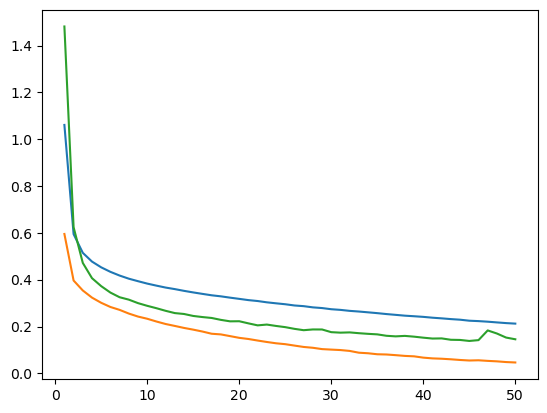

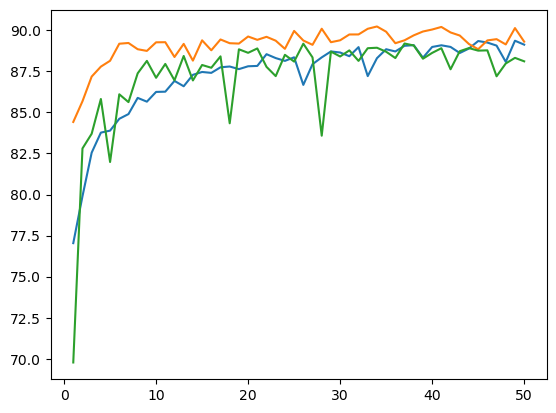

In [79]:
# Initialize the figures before the loop
SGD_fig1, SGD_ax1 = plt.subplots()
SGD_fig2, SGD_ax2 = plt.subplots()

SGD_lr_arr = [0.01,0.1,0.5]

for lr in SGD_lr_arr:
    model, ex1_train_loss_list, ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr, epochs=epochs, train_batch_size=train_batch_size, opt='SGD', dropout_prob=0, init='no', batchnorm='no')

    epochs_vec = range(1,epochs+1)

    # Add a line to the first graph (Training Loss)
    SGD_ax1.plot(epochs_vec, ex1_train_loss_list, label=f'LR={lr}')
    
    # Add a line to the second graph (Validation Accuracy)
    SGD_ax2.plot(epochs_vec, ex1_validation_accuracy_list, label=f'LR={lr}')


In [94]:
# Add labels and legends to the first figure
SGD_ax1.set_xlabel('Epoch #')
SGD_ax1.set_ylabel('Train Loss')
SGD_ax1.set_title('SGD Optimizer - Epoch vs. Train Loss')
SGD_ax1.set_ylim([0,2])
SGD_ax1.legend()

# Add labels and legends to the second figure
SGD_ax2.set_xlabel('Epoch #')
SGD_ax2.set_ylabel('Validation Accuracy')
SGD_ax2.set_title('SGD Optimizer - Epoch vs. Validation Accuracy')
SGD_ax2.axhline(y=85, color='r', linestyle='--')
SGD_ax2.legend()

SGD_fig1.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/SGD_training_loss_plot.png', dpi=300, bbox_inches='tight')
SGD_fig2.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/SGD_validation_accuracy_plot.png', dpi=300, bbox_inches='tight')

# Show both figures after the loop
plt.show()

NameError: name 'SGD_ax1' is not defined

## Adam

### Test various learning rates and test them for ADAM

  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:02<02:19,  2.85s/it]

Epoch: 0; Validation Accuracy:86.24857522796351%


  4%|▍         | 2/50 [00:05<02:08,  2.67s/it]

Epoch: 1; Validation Accuracy:87.47625379939208%


...

Epoch: 47; Validation Accuracy:10.004274316109422%


 98%|█████████▊| 49/50 [02:01<00:02,  2.43s/it]

Epoch: 48; Validation Accuracy:9.99240121580547%


100%|██████████| 50/50 [02:03<00:00,  2.48s/it]

Epoch: 49; Validation Accuracy:9.99240121580547%


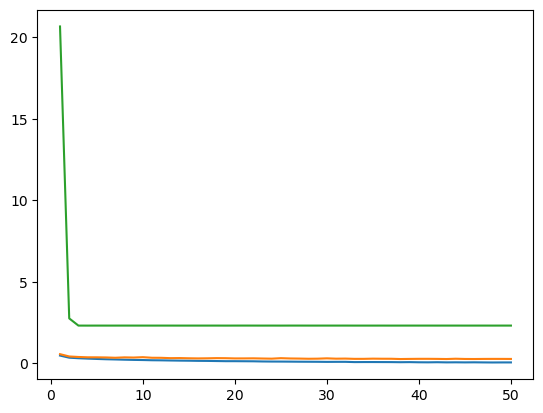

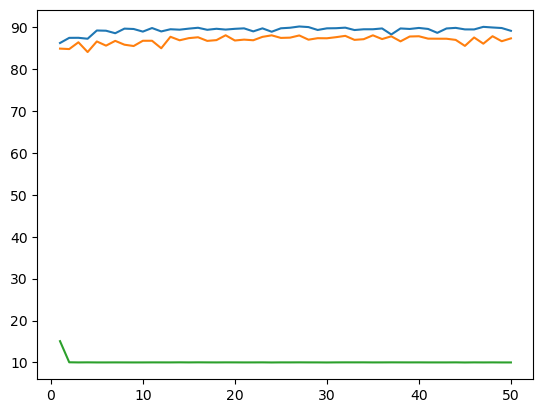

In [81]:
# Initialize the figures before the loop
Adam_fig1, Adam_ax1 = plt.subplots()
Adam_fig2, Adam_ax2 = plt.subplots()

Adam_lr_arr = [0.001,0.01,0.1]

for lr in Adam_lr_arr:
    model, ex1_train_loss_list, ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr, epochs=epochs, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0, init='no', batchnorm='no')

    epochs_vec = range(1,epochs+1)

    # Add a line to the first graph (Training Loss)
    Adam_ax1.plot(epochs_vec, ex1_train_loss_list, label=f'LR={lr}')
    
    # Add a line to the second graph (Validation Accuracy)
    Adam_ax2.plot(epochs_vec, ex1_validation_accuracy_list, label=f'LR={lr}')



In [82]:
# Add labels and legends to the first figure
Adam_ax1.set_xlabel('Epoch #')
Adam_ax1.set_ylabel('Train Loss')
Adam_ax1.set_title('Adam Optimizer - Epoch vs. Train Loss')
Adam_ax1.set_ylim([0,2])
Adam_ax1.legend()

# Add labels and legends to the second figure
Adam_ax2.set_xlabel('Epoch #')
Adam_ax2.set_ylabel('Validation Accuracy')
Adam_ax2.set_title('Adam Optimizer - Epoch vs. Validation Accuracy')
Adam_ax2.axhline(y=85, color='r', linestyle='--')
Adam_ax2.legend()

Adam_fig1.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/Adam_training_loss_plot.png', dpi=300, bbox_inches='tight')
Adam_fig2.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/Adam_validation_accuracy_plot.png', dpi=300, bbox_inches='tight')

# Show both figures after the loop
plt.show()

## RMS Prop

### plot different learning rates with RMSProp

  2%|▏         | 1/50 [00:02<02:11,  2.69s/it]

Epoch: 0; Validation Accuracy:84.88316869300911%


  4%|▍         | 2/50 [00:05<02:04,  2.59s/it]

Epoch: 1; Validation Accuracy:85.92087765957447%


  6%|▌         | 3/50 [00:07<02:00,  2.57s/it]

...

Epoch: 47; Validation Accuracy:87.41688829787235%


 98%|█████████▊| 49/50 [02:02<00:02,  2.42s/it]

Epoch: 48; Validation Accuracy:87.38601823708207%


100%|██████████| 50/50 [02:05<00:00,  2.50s/it]

Epoch: 49; Validation Accuracy:87.54036854103344%


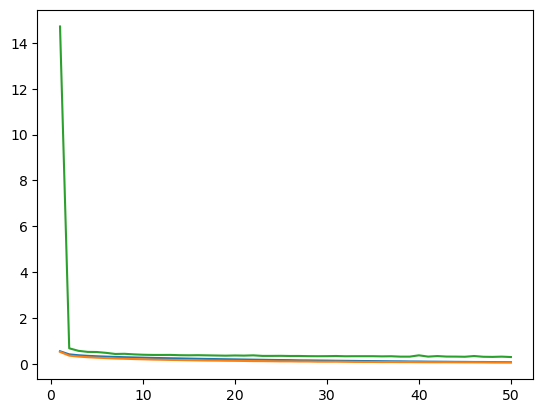

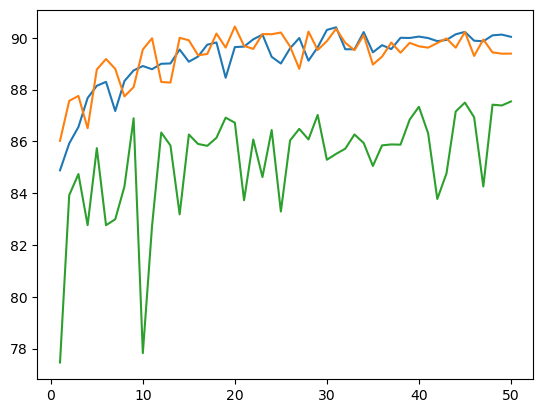

In [83]:
# Initialize the figures before the loop
RMS_fig1, RMS_ax1 = plt.subplots()
RMS_fig2, RMS_ax2 = plt.subplots()

RMS_lr_arr = [0.0001,0.001,0.01]

for lr in RMS_lr_arr:
    model, ex1_train_loss_list, ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr, epochs=epochs, train_batch_size=train_batch_size, opt='RMS', dropout_prob=0, init='no', batchnorm='no')

    epochs_vec = range(1,epochs+1)

    # Add a line to the first graph (Training Loss)
    RMS_ax1.plot(epochs_vec, ex1_train_loss_list, label=f'LR={lr}')
    
    # Add a line to the second graph (Validation Accuracy)
    RMS_ax2.plot(epochs_vec, ex1_validation_accuracy_list, label=f'LR={lr}')


In [84]:

# Add labels and legends to the first figure
RMS_ax1.set_xlabel('Epoch #')
RMS_ax1.set_ylabel('Train Loss')
RMS_ax1.set_title('RMSProp Optimizer - Epoch vs. Train Loss')
RMS_ax1.set_ylim([0,2])
RMS_ax1.legend()

# Add labels and legends to the second figure
RMS_ax2.set_xlabel('Epoch #')
RMS_ax2.set_ylabel('Validation Accuracy')
RMS_ax2.set_title('RMSProp Optimizer - Epoch vs. Validation Accuracy')
RMS_ax2.axhline(y=85, color='r', linestyle='--')
RMS_ax2.legend()

RMS_fig1.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/RMS_training_loss_plot.png', dpi=300, bbox_inches='tight')
RMS_fig2.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/RMS_validation_accuracy_plot.png', dpi=300, bbox_inches='tight')

# Show both figures after the loop
plt.show()

### Run each model with their optimal learning rate and find their accuracy

In [95]:
lr_SGD = 0.1
lr_Adam = 0.001
lr_RMS = 0.001

In [96]:


# train SGD model and find accuracy mean and std
model_SGD, SGD_ex1_train_loss_list, SGD_ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr_SGD, epochs=epochs, train_batch_size=train_batch_size, opt='SGD', dropout_prob=0, init='no', batchnorm='no')
SGD_acc_mean, SGD_acc_std = acc_test(model_SGD, test_batch_size=test_batch_size)

# train Adam model and find accuracy mean and std
model_Adam, Adam_ex1_train_loss_list, Adam_ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr_Adam, epochs=epochs, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0, init='no', batchnorm='no')
Adam_acc_mean, Adam_acc_std = acc_test(model_Adam, test_batch_size=test_batch_size)

# train RMSProp model and find accuracy mean and std
model_RMS, RMS_ex1_train_loss_list, RMS_ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr_RMS, epochs=epochs, train_batch_size=train_batch_size, opt='RMS', dropout_prob=0, init='no', batchnorm='no')
RMS_acc_mean, RMS_acc_std = acc_test(model_RMS, test_batch_size=test_batch_size)



  2%|▏         | 1/50 [00:03<02:34,  3.15s/it]

Epoch: 0; Validation Accuracy:83.28267477203649%


  4%|▍         | 2/50 [00:06<02:27,  3.07s/it]

Epoch: 1; Validation Accuracy:84.35362841945289%


  6%|▌         | 3/50 [00:09<02:20,  2.99s/it]

...

 98%|█████████▊| 49/50 [02:21<00:02,  2.88s/it]

Epoch: 48; Validation Accuracy:90.00284954407294%


100%|██████████| 50/50 [02:24<00:00,  2.88s/it]

Epoch: 49; Validation Accuracy:89.1099924012158%


Total mean accuracy is 88.45541401273886 with std of 4.031721667682866


### plot the accuracy and std of each optimization method

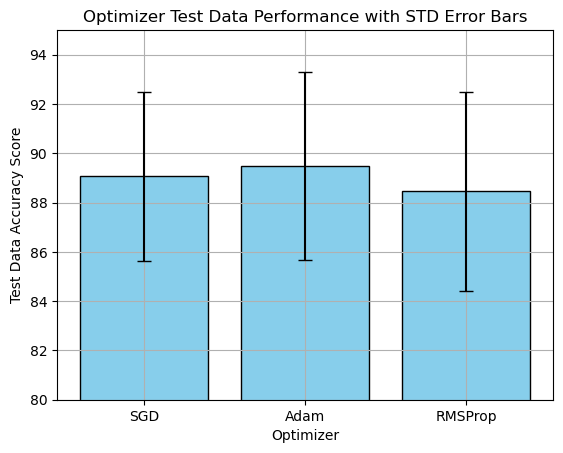

In [97]:
x_labels = np.array(['SGD', 'Adam', 'RMSProp'])

# Define x positions for training (left) and testing (right) 
x_te_opt = np.arange(len(x_labels))  

# Means for training and testing sets
y_te_opt = np.array([SGD_acc_mean, Adam_acc_mean, RMS_acc_mean])

# Standard deviations for training and testing sets
e_te_opt = np.array([SGD_acc_std, Adam_acc_std, RMS_acc_std])

# Plot with slight horizontal offsets for better visualization
plt.bar(x_te_opt, y_te_opt, yerr=e_te_opt, capsize=5, color='skyblue', edgecolor='black')


# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("Optimizer")
plt.ylabel("Test Data Accuracy Score")
plt.ylim([80,95])
plt.title("Optimizer Test Data Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/optcompare_te.png')

## include dropout regularization, compare with other Adam optimizer

In [98]:
# Initialize the figures before the loop
epochs_vec = range(1,epochs+1)

d_prob_arr = [0.1,0.2,0.3]
Adam_acc_mean_darr = np.array([])
Adam_acc_std_darr = np.array([])
for prob in d_prob_arr:
    # train SGD model and find accuracy mean and std
    model_Adam_d, Adam_ex1_train_loss_list_d, Adam_ex1_validation_accuracy_list_d = train_and_eval(hidden_lays=layers_base, learning_rate=lr_Adam, epochs=epochs, train_batch_size=train_batch_size, opt='Adam', dropout_prob=prob, init='no', batchnorm='no')
    Adam_acc_mean_d, Adam_acc_std_d = acc_test(model_Adam_d, test_batch_size=test_batch_size)

    Adam_acc_mean_darr = np.append(Adam_acc_mean_darr, Adam_acc_mean_d)
    Adam_acc_std_darr = np.append(Adam_acc_std_darr, Adam_acc_std_d)

  2%|▏         | 1/50 [00:03<03:02,  3.72s/it]

Epoch: 0; Validation Accuracy:84.73119300911854%


  4%|▍         | 2/50 [00:07<02:52,  3.58s/it]

Epoch: 1; Validation Accuracy:87.32190349544074%


  6%|▌         | 3/50 [00:10<02:42,  3.46s/it]

...

 98%|█████████▊| 49/50 [02:46<00:03,  3.38s/it]

Epoch: 48; Validation Accuracy:90.18806990881458%


100%|██████████| 50/50 [02:49<00:00,  3.39s/it]

Epoch: 49; Validation Accuracy:89.90074088145897%


Total mean accuracy is 88.7937898089172 with std of 4.229474984782687


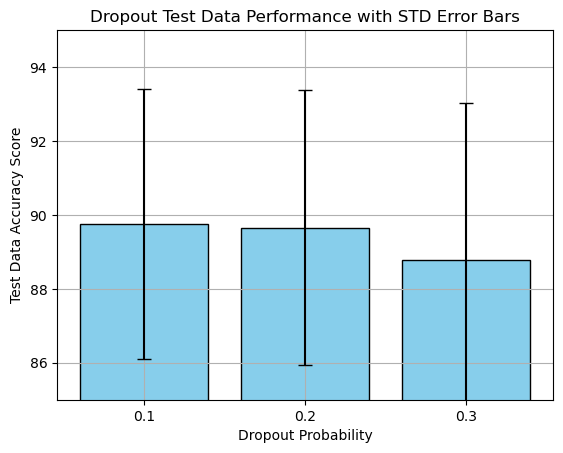

In [99]:
# Add the og Adam to the plot
x_labels = np.array(['0.1', '0.2', '0.3'])

# Define x positions for training (left) and testing (right) 
x_te_opt = np.arange(len(x_labels))  

# Means for training and testing sets
y_te_opt = np.array([Adam_acc_mean_darr[0], Adam_acc_mean_darr[1], Adam_acc_mean_darr[2]])

# Standard deviations for training and testing sets
e_te_opt = np.array([Adam_acc_std_darr[0], Adam_acc_std_darr[1], Adam_acc_std_darr[2]])

# Plot with slight horizontal offsets for better visualization
plt.bar(x_te_opt, y_te_opt, yerr=e_te_opt, capsize=5, color='skyblue', edgecolor='black')


# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("Dropout Probability")
plt.ylabel("Test Data Accuracy Score")
plt.ylim([85,95])
plt.title("Dropout Test Data Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/dropvalcompare_te.png')


In [100]:
# optimal adam with dropout 0.1

model_Adam_d, Adam_ex1_train_loss_list_d, Adam_ex1_validation_accuracy_list_d = train_and_eval(hidden_lays=layers_base, learning_rate=lr_Adam, epochs=epochs, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0.1, init='no', batchnorm='no')
Adam_acc_mea_d, Adam_acc_std_d = acc_test(model_Adam_d, test_batch_size=test_batch_size)

  2%|▏         | 1/50 [00:03<02:45,  3.37s/it]

Epoch: 0; Validation Accuracy:85.22511398176292%


  4%|▍         | 2/50 [00:06<02:39,  3.31s/it]

Epoch: 1; Validation Accuracy:87.34564969604862%


  6%|▌         | 3/50 [00:09<02:35,  3.32s/it]

...

 98%|█████████▊| 49/50 [02:38<00:03,  3.21s/it]

Epoch: 48; Validation Accuracy:90.53476443768996%


100%|██████████| 50/50 [02:41<00:00,  3.22s/it]

Epoch: 49; Validation Accuracy:90.15719984802432%


Total mean accuracy is 89.281449044586 with std of 3.6075424143437167


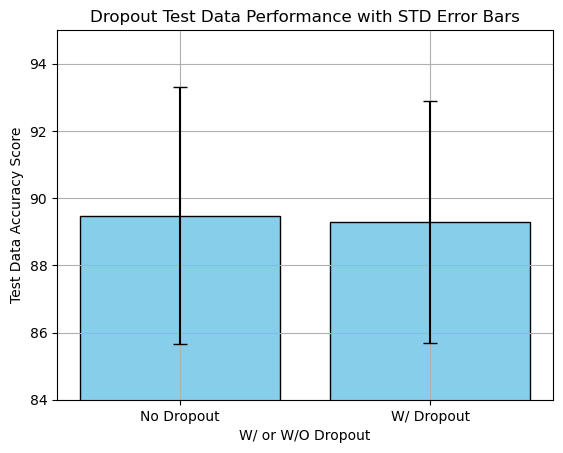

In [104]:
x_labels = np.array(['No Dropout', 'W/ Dropout'])

# Define x positions for training (left) and testing (right) 
x_te_opt = np.arange(len(x_labels))  

# Means for training and testing sets
y_te_opt = np.array([Adam_acc_mean, Adam_acc_mea_d])

# Standard deviations for training and testing sets
e_te_opt = np.array([Adam_acc_std, Adam_acc_std_d])

# Plot with slight horizontal offsets for better visualization
plt.bar(x_te_opt, y_te_opt, yerr=e_te_opt, capsize=5, color='skyblue', edgecolor='black')


# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("W/ or W/O Dropout")
plt.ylabel("Test Data Accuracy Score")
plt.ylim([84,95])
plt.title("Dropout Test Data Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/dropcompare_te.png')

## Evaluate different initializations

### compare 3 initializations

In [108]:
# train SGD model and find accuracy mean and std
model_I_RN, I_RN_ex1_train_loss_list, I_RN_ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr_Adam, epochs=epochs, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0, init='RN', batchnorm='no')
I_RN_acc_mean, I_RN_acc_std = acc_test(model_I_RN, test_batch_size=test_batch_size)

# train Adam model and find accuracy mean and std
model_I_XN, I_XN_ex1_train_loss_list, I_XN_ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr_Adam, epochs=epochs, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0, init='XN', batchnorm='no')
I_XN_acc_mean, I_XN_acc_std = acc_test(model_I_XN, test_batch_size=test_batch_size)

# train RMSProp model and find accuracy mean and std
model_I_KU, I_KU_ex1_train_loss_list, I_KU_ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr_Adam, epochs=epochs, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0, init='KU', batchnorm='no')
I_KU_acc_mean, I_KU_acc_std = acc_test(model_I_KU, test_batch_size=test_batch_size)


  2%|▏         | 1/50 [00:03<02:48,  3.44s/it]

Epoch: 0; Validation Accuracy:85.6667933130699%


  4%|▍         | 2/50 [00:06<02:43,  3.40s/it]

Epoch: 1; Validation Accuracy:87.64010258358664%


  6%|▌         | 3/50 [00:09<02:34,  3.29s/it]

...

 98%|█████████▊| 49/50 [02:31<00:03,  3.07s/it]

Epoch: 48; Validation Accuracy:89.7440159574468%


100%|██████████| 50/50 [02:34<00:00,  3.09s/it]

Epoch: 49; Validation Accuracy:90.00997340425532%


Total mean accuracy is 89.20183121019109 with std of 3.502195005317089


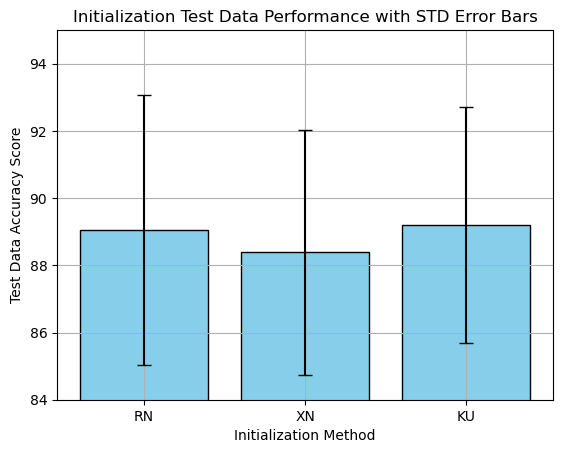

In [110]:
x_labels = np.array(['RN', 'XN', 'KU'])

# Define x positions for training (left) and testing (right) 
x_te_opt = np.arange(len(x_labels))  

# Means for training and testing sets
y_te_opt = np.array([I_RN_acc_mean, I_XN_acc_mean, I_KU_acc_mean])

# Standard deviations for training and testing sets
e_te_opt = np.array([I_RN_acc_std, I_XN_acc_std, I_KU_acc_std])

# Plot with slight horizontal offsets for better visualization
plt.bar(x_te_opt, y_te_opt, yerr=e_te_opt, capsize=5, color='skyblue', edgecolor='black')


# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("Initialization Method")
plt.ylabel("Test Data Accuracy Score")
plt.ylim([84,95])
plt.title("Initialization Test Data Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/initcompare_te.png')

## Batch Normalization

In [111]:
# train SGD model and find accuracy mean and std
model_BN, BN_ex1_train_loss_list, BN_ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr_Adam, epochs=epochs, train_batch_size=train_batch_size, opt='Adam', dropout_prob=0, init='no', batchnorm='yes')
BN_acc_mean, BN_acc_std = acc_test(model_BN, test_batch_size=test_batch_size)

  2%|▏         | 1/50 [00:03<02:42,  3.32s/it]

Epoch: 0; Validation Accuracy:86.44091945288754%


  4%|▍         | 2/50 [00:06<02:37,  3.28s/it]

Epoch: 1; Validation Accuracy:87.39789133738603%


  6%|▌         | 3/50 [00:09<02:35,  3.31s/it]

...

 98%|█████████▊| 49/50 [02:35<00:03,  3.12s/it]

Epoch: 48; Validation Accuracy:90.0622150455927%


100%|██████████| 50/50 [02:38<00:00,  3.18s/it]

Epoch: 49; Validation Accuracy:89.17410714285714%


Total mean accuracy is 88.87340764331209 with std of 3.8449623563469406


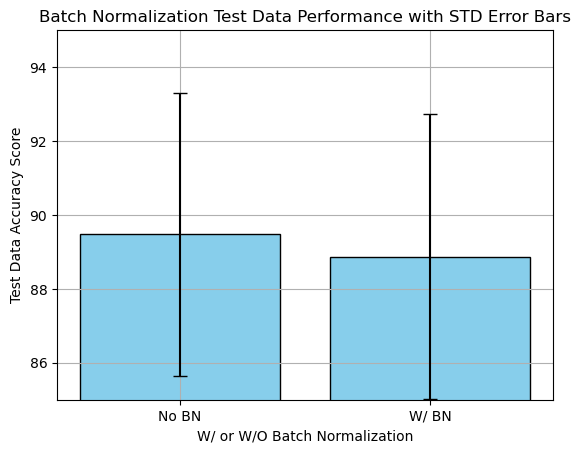

In [113]:
x_labels = np.array(['No BN', 'W/ BN'])

# Define x positions for training (left) and testing (right) 
x_te_opt = np.arange(len(x_labels))  

# Means for training and testing sets
y_te_opt = np.array([Adam_acc_mean, BN_acc_mean])

# Standard deviations for training and testing sets
e_te_opt = np.array([Adam_acc_std, BN_acc_std])

# Plot with slight horizontal offsets for better visualization
plt.bar(x_te_opt, y_te_opt, yerr=e_te_opt, capsize=5, color='skyblue', edgecolor='black')


# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("W/ or W/O Batch Normalization")
plt.ylabel("Test Data Accuracy Score")
plt.ylim([85,95])
plt.title("Batch Normalization Test Data Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/batchcompare_te.png')

## Final architecture

In [70]:
final_acc_mean_arr = np.array([])

num_trials = 5
for i in range(num_trials):
    print(i)
    model_final, final_ex1_train_loss_list, final_ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_base, learning_rate=lr_Adam, epochs=50, train_batch_size=128, opt='Adam', dropout_prob=0.1, init='KU', batchnorm='yes')
    final_acc_mean, final_acc_std = acc_test(model_final, test_batch_size=64)
    final_acc_mean_arr = np.append(final_acc_mean_arr, final_acc_mean)

0


  2%|▏         | 1/50 [00:03<02:52,  3.52s/it]

Epoch: 0; Validation Accuracy:86.83273176291793%


  4%|▍         | 2/50 [00:07<02:48,  3.51s/it]

Epoch: 1; Validation Accuracy:88.31686930091185%


...

 98%|█████████▊| 49/50 [02:56<00:03,  3.51s/it]

Epoch: 48; Validation Accuracy:89.98860182370821%


100%|██████████| 50/50 [03:00<00:00,  3.61s/it]

Epoch: 49; Validation Accuracy:89.71789513677811%


Total mean accuracy is 89.65963375796179 with std of 0.034084024338241835


In [118]:
print(final_acc_mean)
print(final_acc_std)

print(np.mean(final_acc_mean_arr))
print(np.std(final_acc_mean_arr))

final_acc_mean = np.mean(final_acc_mean_arr)
final_acc_std = np.std(final_acc_mean_arr)

89.65963375796179
0.034084024338241835
89.77109872611464
0.33034206107841724


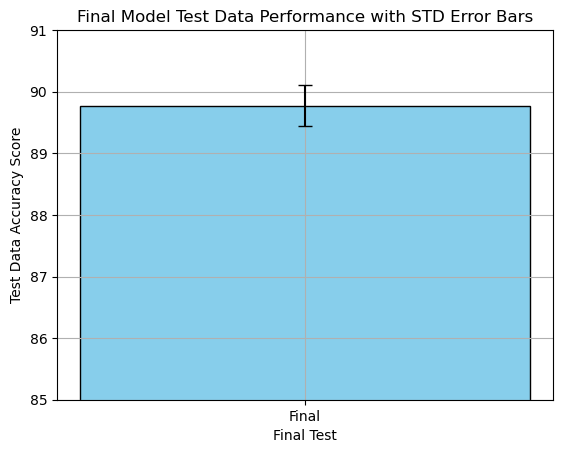

In [119]:
x_labels = np.array(['Final'])

# Define x positions for training (left) and testing (right) 
x_te_opt = np.arange(len(x_labels))  

# Means for training and testing sets
y_te_opt = np.array([final_acc_mean])

# Standard deviations for training and testing sets
e_te_opt = np.array([final_acc_std])

# Plot with slight horizontal offsets for better visualization
plt.bar(x_te_opt, y_te_opt, yerr=e_te_opt, capsize=5, color='skyblue', edgecolor='black')


# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("Final Test")
plt.ylabel("Test Data Accuracy Score")
plt.ylim([85,91])
plt.title("Final Model Test Data Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/final_te.png')

## MNIST

In [120]:
# Use the following code to load and normalize the dataset for training and testing
# It will downlad the dataset into data subfolder (change to your data folder name)
train_dataset = torchvision.datasets.MNIST('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/data/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))

test_dataset = torchvision.datasets.MNIST('/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/data/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))



In [121]:
# Use the following code to create a validation set of 10%
train_indices, val_indices, _, _ = train_test_split(
    range(len(train_dataset)),
    train_dataset.targets,
    stratify=train_dataset.targets,
    test_size=0.1,
)

# Generate training and validation subsets based on indices
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)


In [122]:
train_batch_size_MNIST = 128
test_batch_size_MNIST = 64
layers_MNIST = [512,256]
lr_MNIST = 0.001
epochs = 50
MNIST_acc_mean_arr = np.array([])
MNIST_acc_std_arr = np.array([])
num_trials = 5
for i in range(num_trials):
    model_MNIST, MNIST_ex1_train_loss_list, MNIST_ex1_validation_accuracy_list = train_and_eval(hidden_lays=layers_MNIST, learning_rate=lr_MNIST, epochs=epochs, train_batch_size=train_batch_size_MNIST, opt='Adam', dropout_prob=0.1, init='KU', batchnorm='yes')
    MNIST_acc_mean, MNIST_acc_std = acc_test(model_MNIST, test_batch_size=test_batch_size_MNIST)
    MNIST_acc_mean_arr = np.append(MNIST_acc_mean_arr,MNIST_acc_mean)
    MNIST_acc_mean_std = np.array(MNIST_acc_std_arr,MNIST_acc_std)

  2%|▏         | 1/50 [00:04<03:16,  4.01s/it]

Epoch: 0; Validation Accuracy:96.83463145896656%


  4%|▍         | 2/50 [00:07<03:05,  3.86s/it]

Epoch: 1; Validation Accuracy:97.12908434650457%


  6%|▌         | 3/50 [00:11<03:00,  3.84s/it]

...

 98%|█████████▊| 49/50 [02:43<00:03,  3.39s/it]

Epoch: 48; Validation Accuracy:98.55148176291793%


100%|██████████| 50/50 [02:46<00:00,  3.33s/it]

Epoch: 49; Validation Accuracy:98.36626139817628%


Total mean accuracy is 98.45740445859873 with std of 1.4647707176220623


### plot final Fashion MNIST and final MNIST

[98.40764331 98.37778662 98.4375     98.21855096 98.45740446]


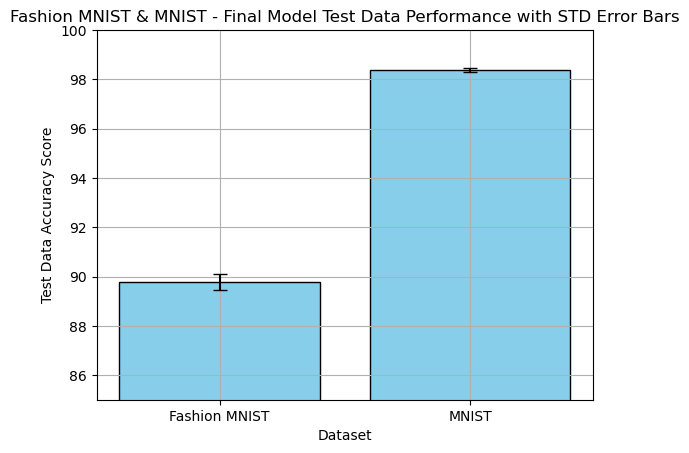

In [124]:
MNIST_acc_mean = np.mean(MNIST_acc_mean_arr)
print(MNIST_acc_mean_arr)
MNIST_acc_std = np.std(MNIST_acc_mean_arr)

x_labels = np.array(['Fashion MNIST', 'MNIST'])

# Define x positions for training (left) and testing (right) 
x_te_opt = np.arange(len(x_labels))  

# Means for training and testing sets
y_te_opt = np.array([final_acc_mean, MNIST_acc_mean])

# Standard deviations for training and testing sets
e_te_opt = np.array([final_acc_std, MNIST_acc_std])

# Plot with slight horizontal offsets for better visualization
plt.bar(x_te_opt, y_te_opt, yerr=e_te_opt, capsize=5, color='skyblue', edgecolor='black')


# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("Dataset")
plt.ylabel("Test Data Accuracy Score")
plt.ylim([85,100])
plt.title("Fashion MNIST & MNIST - Final Model Test Data Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/final_fashionmnistmnist_te.png')

## Apply most successful classifier from hw 3 to Fashion MNIST dataset


In [ ]:
import torchvision.transforms as transforms
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# Load Fashion MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# Convert data to NumPy arrays
Xtraindata = train_dataset.data.numpy().reshape(-1, 28 * 28)  # Flatten images
Xtestdata = test_dataset.data.numpy().reshape(-1, 28 * 28)  
ytrainlabels = train_dataset.targets.numpy()
ytestlabels = test_dataset.targets.numpy()

In [127]:
KNNTe_score_arr = np.array([])
for i in range(num_trials):
    # refit PCA model 
    pca_trial = PCA()
    Xtr_pca_K_trial = pca_trial.fit_transform(Xtraindata)
    Xte_pca_K_trial = pca_trial.transform(Xtestdata)

    # use optimal K value in KNN
    KNNCL = KNeighborsClassifier(n_neighbors=3)
    KNNCL.fit(Xtr_pca_K_trial, ytrainlabels)

    # find accuracy score
    KNNTr_score = KNNCL.score(Xtr_pca_K_trial, ytrainlabels)
    KNNTe_score = KNNCL.score(Xte_pca_K_trial, ytestlabels)

    print(KNNTr_score)
    print(KNNTe_score)

    KNNTe_score_arr = np.append(KNNTe_score_arr,KNNTe_score)

0.9199333333333334
0.8541
0.9199333333333334
0.8541
0.9199333333333334
0.8541
0.9199333333333334
0.8541
0.9199333333333334
0.8541


### compare KNN vs neural network for fashiion MNIST

In [129]:
KNNTe_score_mean = (np.mean(KnnTe_score_arr))*100
KNNTe_score_std = (np.std(KnnTe_score_arr))*100

x_labels = np.array(['KNN', 'FCN Network'])

# Define x positions for training (left) and testing (right) 
x_te_opt = np.arange(len(x_labels))  

# Means for training and testing sets
y_te_opt = np.array([KNNTe_score_mean, final_acc_mean])

# Standard deviations for training and testing sets
e_te_opt = np.array([KNNTe_score_std, final_acc_std])

# Plot with slight horizontal offsets for better visualization
plt.bar(x_te_opt, y_te_opt, yerr=e_te_opt, capsize=5, color='skyblue', edgecolor='black')


# Adjust x-ticks to align with category labels
plt.xticks(np.arange(len(x_labels)), x_labels)

# Labels and title
plt.xlabel("Method")
plt.ylabel("Test Data Accuracy Score")
plt.ylim([83,91])
plt.title("KNN vs. FCN Network Test Data Performance with STD Error Bars")
plt.grid()

# save plot
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW4/figures/KNNFCNcompare_te.png')
plt.show()

NameError: name 'KnnTe_score_arr' is not defined